# Detekcja satelitów: `ffs.py` a `satellites.py`

Jedna klatka syntetyczna z wieloma śladami naraz → maska wejściowa → `find_lines()`
z `ffs.py` (parametry do zmiany w komórce 3) i `satellites.find_satellites()` → detekcje
obu metod na jednym obrazku.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, ZScaleInterval

REPO = os.path.abspath("..")
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from pyaraucaria.ffs import FFS
from pyaraucaria.satellites import find_satellites
from tests import ffs_synth

warnings.simplefilter("ignore", RuntimeWarning)
%matplotlib inline
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}


def show(img, ax, title=None):
    ax.imshow(img, origin="lower", cmap="gray", interpolation="nearest",
              norm=ImageNormalize(img, interval=ZScaleInterval()))
    if title:
        ax.set_title(title)


def line_xy(rho, theta, length=5000):
    # two far-apart points of the line x cos(theta) + y sin(theta) = rho
    c, s = np.cos(theta), np.sin(theta)
    return (np.array([rho * c - length * s, rho * c + length * s]),
            np.array([rho * s + length * c, rho * s - length * c]))


def matches(rho, theta, ln):
    # does the line (rho, theta) describe the trail ln? (angle < 2 deg, < 5 px from its middle)
    dx, dy = ln["x1"] - ln["x0"], ln["y1"] - ln["y0"]
    th_t = np.arctan2(dx, -dy)                                   # normal of the trail
    dth = abs((theta - th_t + np.pi / 2) % np.pi - np.pi / 2)
    xm, ym = (ln["x0"] + ln["x1"]) / 2, (ln["y0"] + ln["y1"]) / 2
    return np.rad2deg(dth) < 2 and abs(xm * np.cos(theta) + ym * np.sin(theta) - rho) < 5

## 1. Klatka

1024×1024, 80 gwiazd (jedna nasycona na śladzie 1), tło 1000 ADU, szum ≈ 32 ADU na piksel.

1. jasny, długi            300 ADU (9.4 sigma/px), FWHM 2.5
2. średni                  120 ADU (3.8 sigma/px), FWHM 2.5
3. słaby                    60 ADU (1.9 sigma/px), FWHM 3.0
4. bardzo słaby             40 ADU (1.2 sigma/px), FWHM 3.0
5. krótki 250 px           150 ADU (4.7 sigma/px), FWHM 2.5
6. bardzo krótki 110 px    120 ADU (3.8 sigma/px), FWHM 2.5
7. szeroki, FWHM 6         100 ADU (3.1 sigma/px), FWHM 6.0
8. przez narożnik          120 ADU (3.8 sigma/px), FWHM 2.5
9. prawie pionowy (3°)     200 ADU (6.2 sigma/px), FWHM 3.0


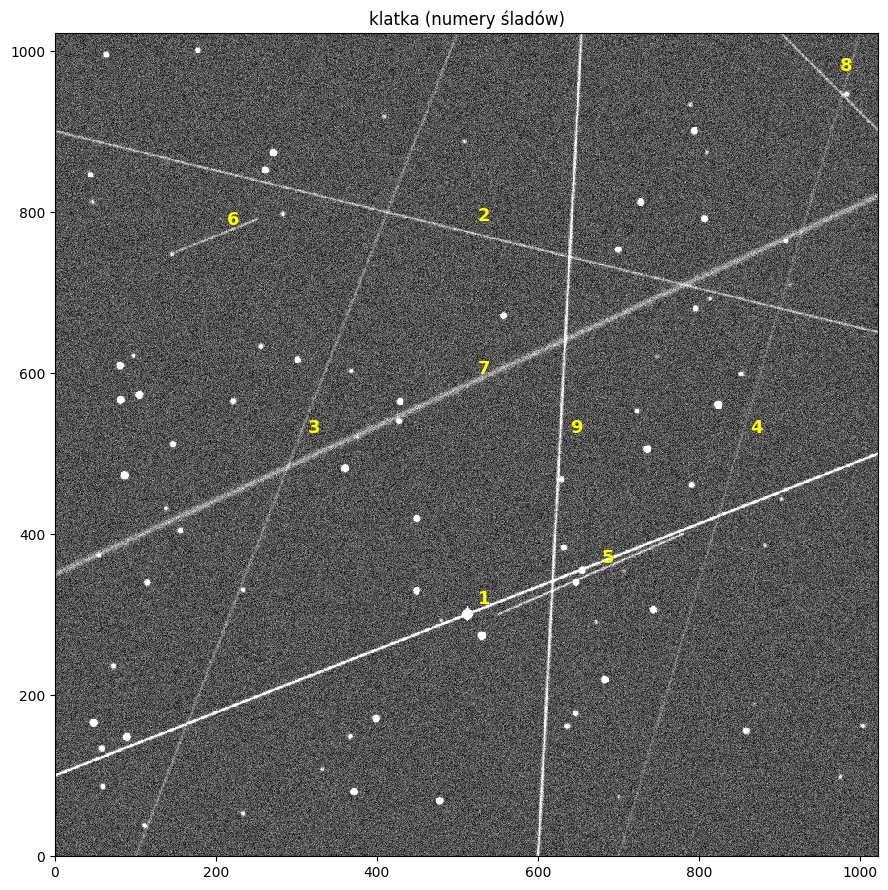

In [2]:
def trail(name, x0, y0, x1, y1, flux, width=2.5):
    return dict(name=name, x0=x0, y0=y0, x1=x1, y1=y1, flux=flux, width=width)


TRAILS = [
    trail("jasny, długi",           0, 100, 1023, 500, 300),
    trail("średni",                 0, 900, 1023, 650, 120),
    trail("słaby",                100,   0,  500, 1023, 60, 3.0),
    trail("bardzo słaby",         700,   0, 1000, 1023, 40, 3.0),
    trail("krótki 250 px",        550, 300,  780,  400, 150),
    trail("bardzo krótki 110 px", 150, 750,  250,  790, 120),
    trail("szeroki, FWHM 6",        0, 350, 1023,  820, 100, 6.0),
    trail("przez narożnik",       900, 1023, 1023, 900, 120),
    trail("prawie pionowy (3°)",  600,   0, 653.6, 1023, 200, 3.0),
]
SHAPE = (1024, 1024)
stars = ffs_synth.star_field(n=80, shape=SHAPE, seed=11) + [dict(x=512.0, y=300.2, flux=4e6, fwhm=4.0)]
frame = ffs_synth.make_frame(shape=SHAPE, stars=stars, sky=1000, saturation=45000,
                             lines=[{k: v for k, v in t.items() if k != "name"} for t in TRAILS], seed=12)
image = frame.image

for i, t in enumerate(TRAILS, 1):
    print(f"{i}. {t['name']:22s} {t['flux']:4.0f} ADU ({t['flux'] / 32:.1f} sigma/px), FWHM {t['width']}")

fig, ax = plt.subplots(figsize=(9, 9))
show(image, ax, "klatka (numery śladów)")
for i, t in enumerate(TRAILS, 1):
    ax.annotate(str(i), ((t["x0"] + t["x1"]) / 2, (t["y0"] + t["y1"]) / 2), color="yellow",
                fontsize=13, fontweight="bold", xytext=(8, 8), textcoords="offset points")
ax.set_xlim(0, SHAPE[1] - 1); ax.set_ylim(0, SHAPE[0] - 1)
plt.tight_layout()

## 2. Maska wejściowa: `mk_stats()` → `self.maska`

Piksele > mediana + 3·q_sigma — to one głosują w transformacie Hougha.

median = 1001.5, q_sigma = 33.4, w masce 15443 px (1.47%)


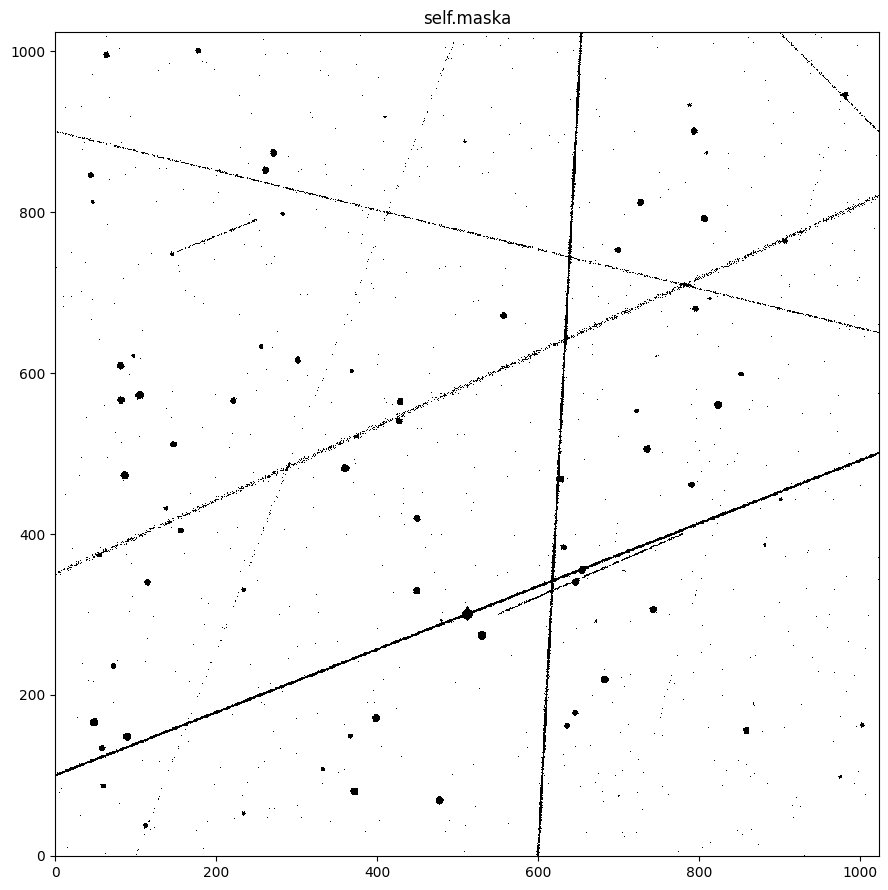

In [3]:
ffs = FFS(image)
ffs.mk_stats()
print(f"median = {ffs.median:.1f}, q_sigma = {ffs.q_sigma:.1f}, "
      f"w masce {ffs.maska.sum()} px ({100 * ffs.maska.mean():.2f}%)")

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(ffs.maska, origin="lower", cmap="gray_r", interpolation="nearest")
ax.set_title("self.maska")
plt.tight_layout()

## 3. Detekcja: `find_lines()` (ffs.py) i `find_satellites()` (satellites.py)

Parametry Twojej funkcji — zmień i uruchom komórkę ponownie.

In [4]:
FFS_PARAMS = dict(
    min_length=30,        # minimalna liczba głosów (wstępny filtr kandydatów)
    fwhm=4.0,             # typowa szerokość śladu; odcinek musi mieć >= 10 * fwhm
    max_gap=5,            # największa dopuszczalna przerwa w odcinku [px]
    min_fill=0.5,         # minimalna zajętość odcinka przez piksele maski
    half_width=3.0,       # piksele w tej odległości od linii są usuwane po jej przyjęciu
    steps=None,           # liczba kątów theta; None = dobierana z rozmiaru klatki
    max_shift=1.0,        # o ile px linia może odjechać na końcu przez siatkę kątów
    max_candidates=100,   # najwięcej sprawdzanych kandydatów
)

ffs.find_lines(**FFS_PARAMS)
sat, sat_mask = find_satellites(image, saturation=45000)
sat = sat[sat["kind"] == "satellite"]

print(f"ffs.py:        {len(ffs.lines_val)} linii (steps = {len(ffs.hough_theta)})")
print(f"satellites.py: {len(sat)} śladów\n")
print(f"{'ślad':26s} {'ffs.py':>7s} {'satellites.py':>14s}")
for i, t in enumerate(TRAILS, 1):
    in_ffs = any(matches(r, th, t) for r, th in zip(ffs.lines_rho, ffs.lines_theta))
    in_sat = any(matches(r["rho"], r["theta"], t) for r in sat)
    print(f"{i}. {t['name']:23s} {'tak' if in_ffs else '-':>7s} {'tak' if in_sat else '-':>14s}")
false_ffs = sum(not any(matches(r, th, t) for t in TRAILS) for r, th in zip(ffs.lines_rho, ffs.lines_theta))
false_sat = sum(not any(matches(r["rho"], r["theta"], t) for t in TRAILS) for r in sat)
print(f"\nfałszywe wykrycia: ffs.py {false_ffs}, satellites.py {false_sat}")

ffs.py:        7 linii (steps = 1138)
satellites.py: 9 śladów

ślad                        ffs.py  satellites.py
1. jasny, długi                tak            tak
2. średni                      tak            tak
3. słaby                         -            tak
4. bardzo słaby                  -            tak
5. krótki 250 px               tak            tak
6. bardzo krótki 110 px        tak            tak
7. szeroki, FWHM 6             tak            tak
8. przez narożnik              tak            tak
9. prawie pionowy (3°)         tak            tak

fałszywe wykrycia: ffs.py 0, satellites.py 0


## 4. Detekcje obu metod

**Czerwony prostokąt** — odcinki z `ffs.py`, **cyan prostokąt** — odcinki z `satellites.py`, żółte numery — prawdziwe ślady (widoczne w środku obwiedni).

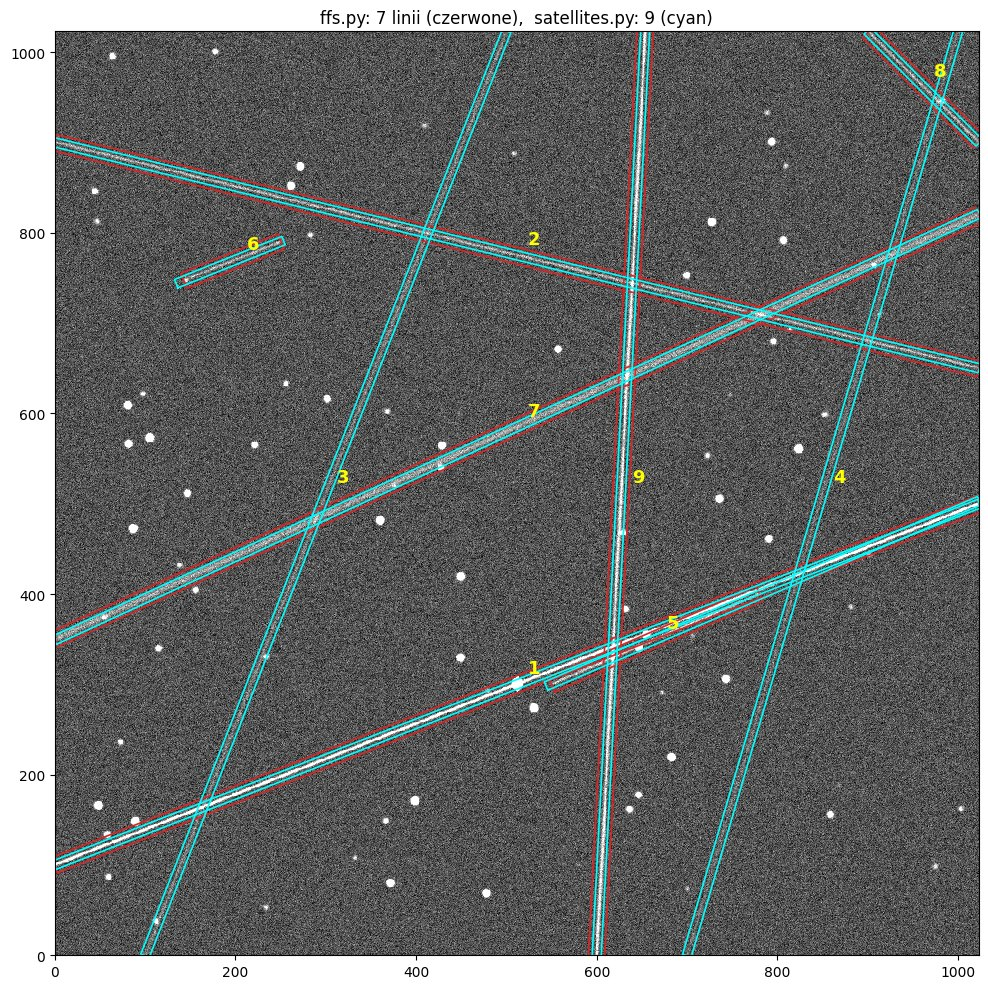

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
show(image, ax, f"ffs.py: {len(ffs.lines_val)} linii (czerwone),  satellites.py: {len(sat)} (cyan)")
for rho, th, x0, y0, x1, y1 in zip(ffs.lines_rho, ffs.lines_theta, ffs.lines_x0, ffs.lines_y0,
                                   ffs.lines_x1, ffs.lines_y1):   # ffs.py: box at +-9 px
    c, s, d = np.cos(th), np.sin(th), 9.0
    ax.plot([x0 + d * c, x1 + d * c, x1 - d * c, x0 - d * c, x0 + d * c],
            [y0 + d * s, y1 + d * s, y1 - d * s, y0 - d * s, y0 + d * s], color="tab:red", lw=1.2)
for r in sat:                                                    # satellites.py: box at +-5 px
    c, s, d = np.cos(r["theta"]), np.sin(r["theta"]), 5.0
    bx = [r["x0"] + d * c, r["x1"] + d * c, r["x1"] - d * c, r["x0"] - d * c, r["x0"] + d * c]
    by = [r["y0"] + d * s, r["y1"] + d * s, r["y1"] - d * s, r["y0"] - d * s, r["y0"] + d * s]
    ax.plot(bx, by, color="cyan", lw=1.2)
for i, t in enumerate(TRAILS, 1):
    ax.annotate(str(i), ((t["x0"] + t["x1"]) / 2, (t["y0"] + t["y1"]) / 2), color="yellow",
                fontsize=13, fontweight="bold", xytext=(8, 8), textcoords="offset points")
ax.set_xlim(0, SHAPE[1] - 1); ax.set_ylim(0, SHAPE[0] - 1)
plt.tight_layout()

## 5. Maska linii: `ffs.masks["lines"]`

Piksele w odległości ≤ `half_width` od wykrytych odcinków — do wyświetlenia (np. w FitsView)
albo do pominięcia w fotometrii (`mask=`).

Pixels within 3.0 px of the detected line segments (find_lines)
w masce: 28853 px (2.75% klatki)


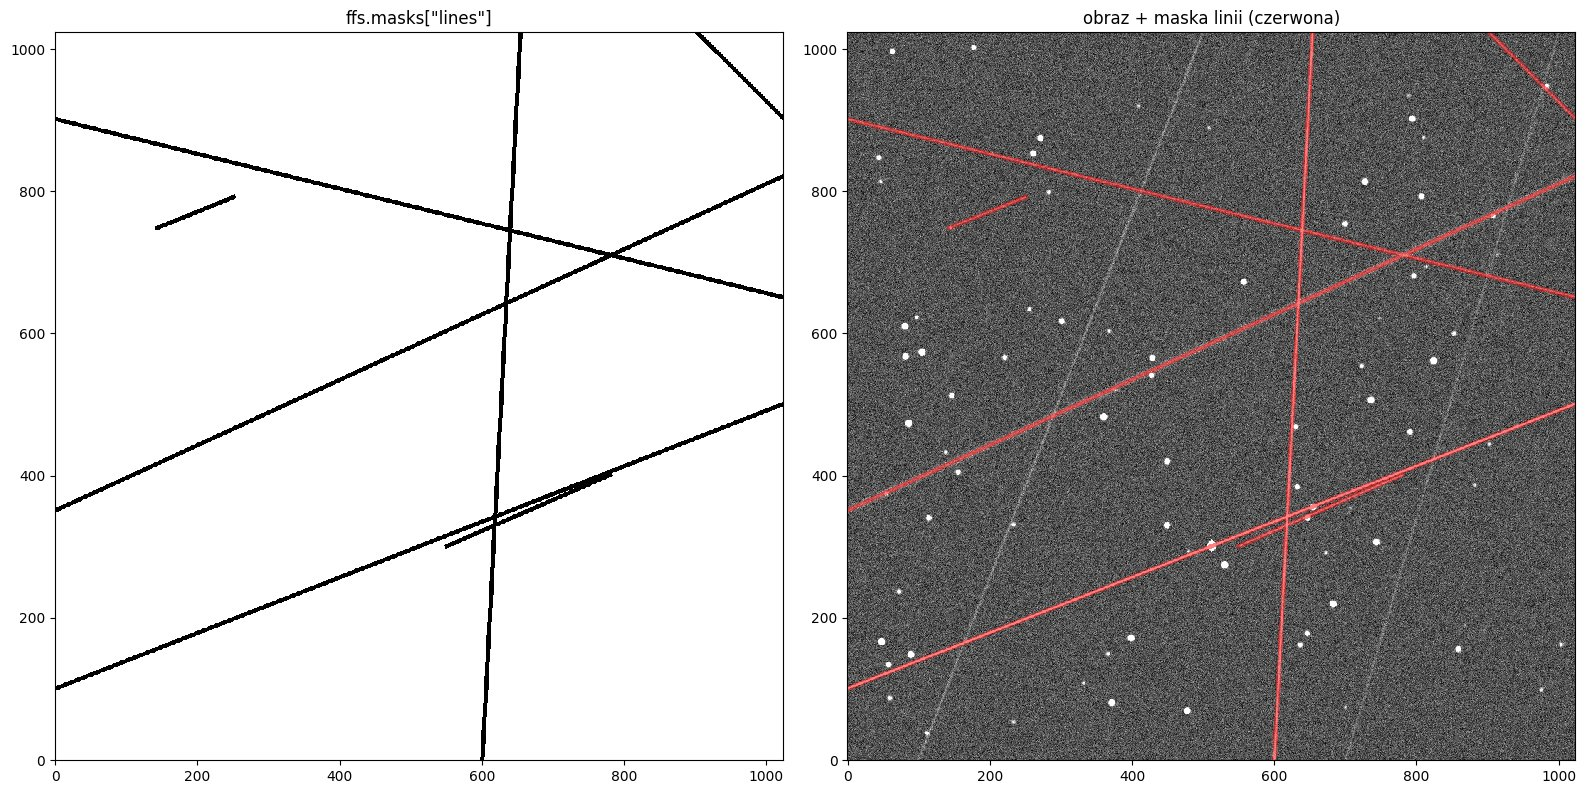

In [6]:
line_mask = ffs.masks["lines"]
print(ffs.masks_description["lines"])
print(f"w masce: {line_mask.sum()} px ({100 * line_mask.mean():.2f}% klatki)")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(line_mask, origin="lower", cmap="gray_r", interpolation="nearest")
axes[0].set_title('ffs.masks["lines"]')
show(image, axes[1], "obraz + maska linii (czerwona)")
axes[1].imshow(np.ma.masked_where(~line_mask, line_mask), origin="lower", cmap="autumn",
               alpha=0.5, interpolation="nearest")
plt.tight_layout()